In [5]:
!pip install scikit-learn




  Using cached scikit_learn-1.5.2-cp39-cp39-macosx_12_0_arm64.whl.metadata (13 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp39-cp39-macosx_12_0_arm64.whl (11.0 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)


In [1]:
from sklearn.cluster import KMeans
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import arcgis
import getpass
from arcgis.mapping import WebMap
import zipfile

/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
populations = gpd.read_file('/Users/ushashi/Documents/codes/blocksandtract_economic_final.shp').to_crs('epsg:26985')
populations


,OBJECTID,BLKGRP,BLOCK,GEOID_left,Bl_totalpo,TRACT,GEOCODE,STATE,Longitude,Latitude,...,eighteento,65 years a,TotalPopul,Bl_incomep,Bl_healthi,pop_weight,PerCapitaI,HI_block,age_18to65,geometry
0,1,1,1004,7500000US110010001021004,62,000102,110010001021004,11,-77.061272,38.905555,...,2132,857,-0.077246,168461.0,3127.0,0.018686,3147.854732,58.430983,39.838457,"POLYGON ((394049.812 138798.76, 394109.244 138..."
1,2,1,1006,7500000US110010001021006,265,000102,110010001021006,11,-77.061272,38.905555,...,2132,857,-0.077246,168461.0,3127.0,0.079867,13454.540386,249.745329,170.277275,"POLYGON ((394813.175 138308.122, 394906 138617..."
2,3,1,1001,7500000US110010001021001,62,000102,110010001021001,11,-77.061272,38.905555,...,2132,857,-0.077246,168461.0,3127.0,0.018686,3147.854732,58.430983,39.838457,"POLYGON ((394162.164 138977.622, 394167.541 13..."
3,4,3,3009,7500000US110010014023009,163,001402,110010014023009,11,-77.063096,38.960613,...,1749,881,0.058907,105522.0,3409.0,0.046893,4948.241082,159.858170,82.015823,"POLYGON ((393845.418 143274.238, 393854.095 14..."
4,5,1,1009,7500000US110010024001009,60,002400,110010024001009,11,-77.022408,38.941790,...,3127,486,0.563018,66538.0,3818.0,0.014775,983.078060,56.409751,46.200443,"POLYGON ((398143.683 141091.068, 398309.365 14..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6007,6008,1,1000,7500000US110010075031000,59,007503,110010075031000,11,-76.987092,38.864080,...,1486,220,-0.596006,25683.0,2518.0,0.021723,557.914948,54.698822,32.280560,"POLYGON ((401268.083 133121.46, 401290.458 133..."
6008,6009,2,2008,7500000US110010075032008,439,007503,110010075032008,11,-76.987092,38.864080,...,1486,220,-0.596006,25683.0,2518.0,0.161635,4151.265464,406.996318,240.189249,"POLYGON ((401365.085 132756.484, 401372.368 13..."
6009,6010,5,5021,7500000US110010076015021,63,007601,110010076015021,11,-76.979969,38.871477,...,3495,606,1.644486,38816.0,5180.0,0.011851,460.009029,61.388262,41.419300,"POLYGON ((401291.137 133307.956, 401323.421 13..."
6010,6011,1,1017,7500000US110010075031017,70,007503,110010075031017,11,-76.987092,38.864080,...,1486,220,-0.596006,25683.0,2518.0,0.025773,661.932990,64.896907,38.298969,"POLYGON ((401224.806 132931.741, 401234.086 13..."


      OBJECTID  BLKGRP BLOCK                GEOID_left  Bl_totalpo   TRACT  \
0            1       1  1004  7500000US110010001021004    0.019941  000102   
1            2       1  1006  7500000US110010001021006    0.086303  000102   
2            3       1  1001  7500000US110010001021001    0.019941  000102   
3            4       3  3009  7500000US110010014023009    0.052958  001402   
4            5       1  1009  7500000US110010024001009    0.019287  002400   
...        ...     ...   ...                       ...         ...     ...   
6007      6008       1  1000  7500000US110010075031000    0.018960  007503   
6008      6009       2  2008  7500000US110010075032008    0.143184  007503   
6009      6010       5  5021  7500000US110010076015021    0.020268  007601   
6010      6011       1  1017  7500000US110010075031017    0.022556  007503   
6011      6012       1  1011  7500000US110010095041011    0.019941  009504   

              GEOCODE  STATE  Longitude   Latitude  Total Popu 

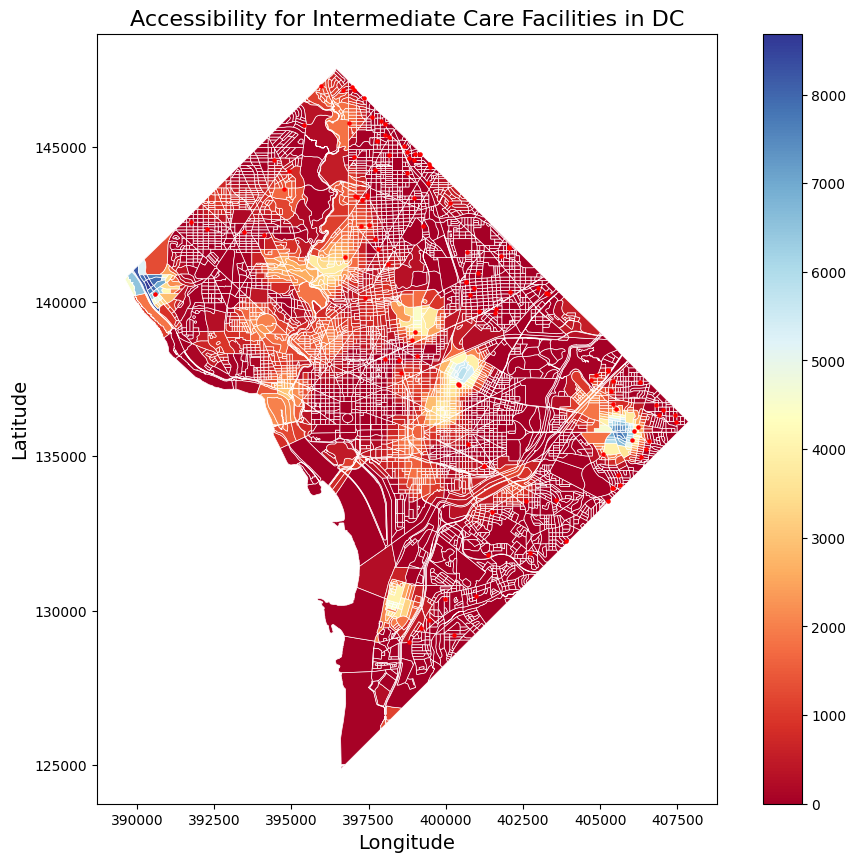

In [4]:


# Load DC ICF data
schools = gpd.read_file('/Users/ushashi/Documents/codes/Intermediate_Care_Facilities.shp').to_crs('epsg:26985')
pd.set_option('display.max_columns', None)

# Load population data
populations = gpd.read_file('/Users/ushashi/Documents/codes/blocksandtract_economic_final.shp').to_crs('epsg:26985')
populations

populations['Bl_totalpo']= populations['Bl_totalpo'].fillna(0)
populations['PerCapitaI']= populations['PerCapitaI'].fillna(0)
populations['HI_block']= populations['HI_block'].fillna(0)
populations['age_18to65'] = populations['age_18to65'].fillna(0)
populations['above_65'] = populations['65 years a'].fillna(0)

# Normalize the additional variables
populations['Bl_totalpo'] = (populations['Bl_totalpo'] - populations['Bl_totalpo'].min()) / (populations['Bl_totalpo'].max() - populations['Bl_totalpo'].min())
populations['PerCapitaI'] = (populations['PerCapitaI'] - populations['PerCapitaI'].min()) /(populations['PerCapitaI'].max() - populations['PerCapitaI'].min())
populations['HI_block'] = (populations['HI_block'] - populations['HI_block'].min()) / (populations['HI_block'].max() - populations['HI_block'].min())
populations['age_18to65'] = (populations['age_18to65'] - populations['age_18to65'].min()) /(populations['age_18to65'].max() - populations['age_18to65'].min())
populations['above_65'] = (populations['above_65'] - populations['above_65'].min()) /(populations['above_65'].max() - populations['above_65'].min())

print(populations)
# Set constant scaling factor J
J = 1

# Set distance decay parameter for time
d0_time = 900  # 15 minutes in seconds

# Define distance decay function for time
def time_decay(distance, d0=d0_time):
    return (np.exp(-0.5 * (distance / d0) ** 2) - np.exp(-0.5)) / (1 - np.exp(-0.5))

# Precompute centroid coordinates
schools_coords = np.array(list(schools.geometry.centroid.apply(lambda geom: (geom.x, geom.y))))
populations_coords = np.array(list(populations.geometry.centroid.apply(lambda geom: (geom.x, geom.y))))

# Create spatial index for populations
pop_tree = cKDTree(populations_coords)

# Calculate weights for each school
weights = np.zeros(len(schools))

# Efficiently calculate distances and weights
for idx, school in schools.iterrows():
    school_coords = np.array([school.geometry.centroid.x, school.geometry.centroid.y])
    distances, indices = pop_tree.query(school_coords, k=len(populations), distance_upper_bound=d0_time)
    
    valid_indices = indices[distances <= d0_time]
    valid_distances = distances[distances <= d0_time]
    
    for i, distance in zip(valid_indices, valid_distances):
        if i < len(populations) and distance <= d0_time:
            weight_factor = (
                populations.at[i, 'Total Popu'] + 
                populations.at[i, 'PerCapitaI'] +
                populations.at[i, 'HI_block'] +
                populations.at[i, 'age_18to65']
            )
            weights[idx] += weight_factor * time_decay(distance)

# Calculate accessibility for each census tract and school
accessibility = np.zeros((len(populations), len(schools)))

# Efficiently calculate distances and demands
for school_idx, school in schools.iterrows():
    demand = np.zeros(len(populations))
    school_coords = np.array([school.geometry.centroid.x, school.geometry.centroid.y])
    distances, indices = pop_tree.query(school_coords, k=len(populations), distance_upper_bound=d0_time)
    
    valid_indices = indices[distances <= d0_time]
    valid_distances = distances[distances <= d0_time]
    
    for i, distance in zip(valid_indices, valid_distances):
        if i < len(populations) and distance <= d0_time:
            demand[i] = populations.at[i, 'Total Popu'] * time_decay(distance)
    
    for origin_idx, origin in populations.iterrows():
        origin_coords = np.array([origin.geometry.centroid.x, origin.geometry.centroid.y])
        distances, indices = pop_tree.query(origin_coords, k=len(schools), distance_upper_bound=d0_time)
        
        valid_indices = indices[distances <= d0_time]
        valid_distances = distances[distances <= d0_time]
        
        weight_origin = np.sum([
            weights[valid_idx] * time_decay(distance) 
            for distance, valid_idx in zip(valid_distances, valid_indices) 
            if valid_idx < len(schools) and distance <= d0_time
        ])
        
        supply = school['BEDS']
        demand_j = np.sum(demand[demand > 0])
        #print(f"Origin {origin_idx} - Demand: {demand_j}")

        if demand_j > 0:
            accessibility[origin_idx, school_idx] = J * supply * weight_origin / demand_j
        else:
            accessibility[origin_idx, school_idx] = 0

print("NaN values in accessibility array:")
print(np.isnan(accessibility).sum())

# Calculate total accessibility for each origin
populations['accessibility'] = np.sum(accessibility, axis=1)

# Check for NaN values in the total accessibility column
print("NaN values in total accessibility column:")
print(populations['accessibility'].isnull().sum())
#populations['accessibility']=populations['accessibility'].fillna(0)
print(populations['accessibility'])
# Save results to a CSV file
populations.to_csv("access_ICF_final1.csv", index=False)
sort = populations.sort_values(by='accessibility', ascending=False)
pd.set_option('display.max_columns', None)

print(sort)

blocks_with_zero_accessibility = sort[sort['accessibility'] == 0]

# Get the total number of such blocks
total_blocks_with_zero_accessibility = len(blocks_with_zero_accessibility)

# Display the result
print("Total number of blocks with accessibility score of 0:", total_blocks_with_zero_accessibility)

print(populations.columns)


# Plot accessibility on the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot census tracts with accessibility values
populations.plot(column='accessibility', cmap='RdYlBu', linewidth=0.5, edgecolor='white', legend=True, ax=ax)

# Plot schools on the map
schools.plot(ax=ax, color='red', markersize=5)

# Set axis labels and title
ax.set_title('Accessibility for Intermediate Care Facilities in DC', fontsize=16)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.show()

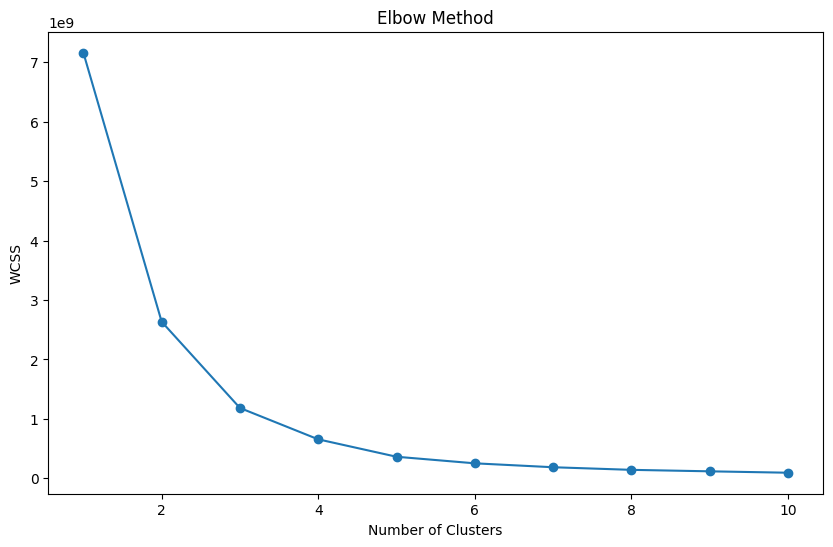

In [5]:
# Select relevant columns for clustering
clustering_data = populations[['accessibility', 'Bl_totalpo', 'PerCapitaI', 'HI_block', 'age_18to65']]


wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(clustering_data)
    wcss.append(kmeans.inertia_)  # WCSS for each value of i

# Plot the Elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

# Try clustering with different numbers of clusters and compute silhouette scores
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(clustering_data)
    silhouette_avg = silhouette_score(clustering_data, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is {silhouette_avg}")


For n_clusters = 2, the average silhouette_score is 0.7620920739394529
For n_clusters = 3, the average silhouette_score is 0.7164144110809096
For n_clusters = 4, the average silhouette_score is 0.7121831734410389
For n_clusters = 5, the average silhouette_score is 0.7203528702664658
For n_clusters = 6, the average silhouette_score is 0.7256577780796322
For n_clusters = 7, the average silhouette_score is 0.7257559883366027
For n_clusters = 8, the average silhouette_score is 0.7273172200273579
For n_clusters = 9, the average silhouette_score is 0.7343807072603742
For n_clusters = 10, the average silhouette_score is 0.7348102280990939


In [7]:
clustering_data = populations[['accessibility', 'Bl_totalpo', 'PerCapitaI', 'HI_block', 'age_18to65']]


In [8]:
from sklearn.cluster import KMeans

# Perform K-Means clustering
kmeans = KMeans(n_clusters=6, random_state=42)
populations['cluster'] = kmeans.fit_predict(clustering_data)
populations

,OBJECTID,BLKGRP,BLOCK,GEOID_left,Bl_totalpo,TRACT,GEOCODE,STATE,Longitude,Latitude,Total Popu,Total Po_1,Total Po_2,Total po_3,eighteento,65 years a,TotalPopul,Bl_incomep,Bl_healthi,pop_weight,PerCapitaI,HI_block,age_18to65,geometry,above_65,accessibility,cluster
0,1,1,1004,7500000US110010001021004,0.019941,000102,110010001021004,11,-77.061272,38.905555,3318,1665,1653,329,2132,857,-0.077246,168461.0,3127.0,0.018686,0.038399,0.016381,0.013093,"POLYGON ((394049.812 138798.76, 394109.244 138...",0.515334,1396.196206,3
1,2,1,1006,7500000US110010001021006,0.086303,000102,110010001021006,11,-77.061272,38.905555,3318,1665,1653,329,2132,857,-0.077246,168461.0,3127.0,0.079867,0.164125,0.070017,0.056719,"POLYGON ((394813.175 138308.122, 394906 138617...",0.515334,1149.542398,3
2,3,1,1001,7500000US110010001021001,0.019941,000102,110010001021001,11,-77.061272,38.905555,3318,1665,1653,329,2132,857,-0.077246,168461.0,3127.0,0.018686,0.038399,0.016381,0.013093,"POLYGON ((394162.164 138977.622, 394167.541 13...",0.515334,1774.968524,5
3,4,3,3009,7500000US110010014023009,0.052958,001402,110010014023009,11,-77.063096,38.960613,3476,1656,1820,846,1749,881,0.058907,105522.0,3409.0,0.046893,0.060361,0.044817,0.027200,"POLYGON ((393845.418 143274.238, 393854.095 14...",0.529765,683.541815,4
4,5,1,1009,7500000US110010024001009,0.019287,002400,110010024001009,11,-77.022408,38.941790,4061,1996,2065,448,3127,486,0.563018,66538.0,3818.0,0.014775,0.011992,0.015815,0.015221,"POLYGON ((398143.683 141091.068, 398309.365 14...",0.292243,651.372855,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6007,6008,1,1000,7500000US110010075031000,0.018960,007503,110010075031000,11,-76.987092,38.864080,2716,1291,1425,1010,1486,220,-0.596006,25683.0,2518.0,0.021723,0.006806,0.015335,0.010566,"POLYGON ((401268.083 133121.46, 401290.458 133...",0.132291,368.457712,4
6008,6009,2,2008,7500000US110010075032008,0.143184,007503,110010075032008,11,-76.987092,38.864080,2716,1291,1425,1010,1486,220,-0.596006,25683.0,2518.0,0.161635,0.050639,0.114103,0.080101,"POLYGON ((401365.085 132756.484, 401372.368 13...",0.132291,0.000000,1
6009,6010,5,5021,7500000US110010076015021,0.020268,007601,110010076015021,11,-76.979969,38.871477,5316,2226,3090,1215,3495,606,1.644486,38816.0,5180.0,0.011851,0.005611,0.017210,0.013622,"POLYGON ((401291.137 133307.956, 401323.421 13...",0.364402,431.569509,4
6010,6011,1,1017,7500000US110010075031017,0.022556,007503,110010075031017,11,-76.987092,38.864080,2716,1291,1425,1010,1486,220,-0.596006,25683.0,2518.0,0.025773,0.008075,0.018194,0.012579,"POLYGON ((401224.806 132931.741, 401234.086 13...",0.132291,291.131251,1


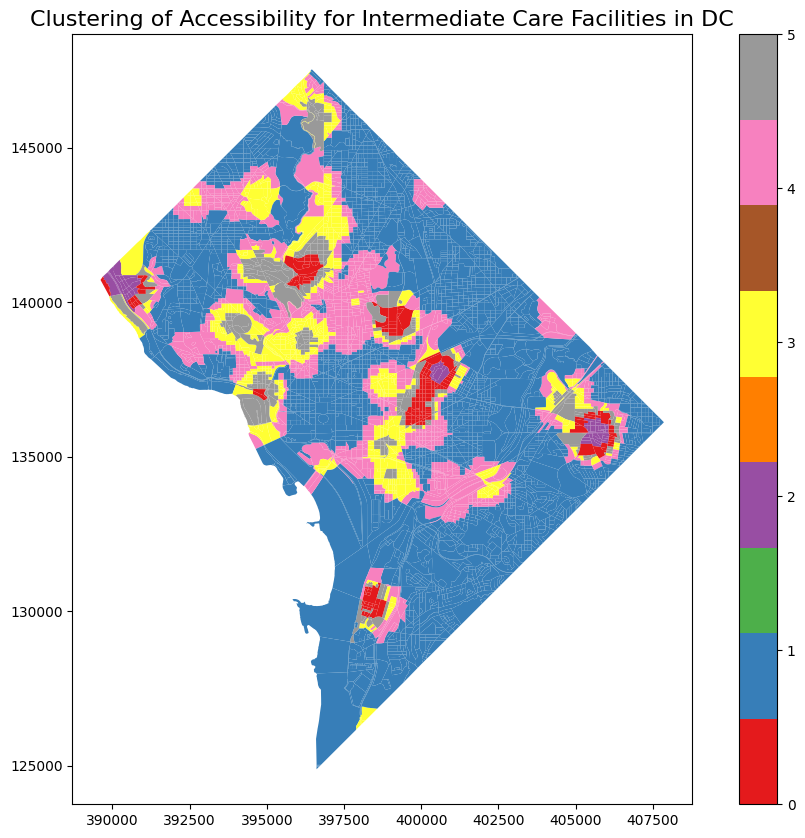

In [9]:


# Plot the results
fig, ax = plt.subplots(figsize=(12, 10))
populations.plot(column='cluster', cmap='Set1', linewidth=0.5, legend=True, ax=ax)
ax.set_title('Clustering of Accessibility for Intermediate Care Facilities in DC', fontsize=16)
plt.show()


In [10]:
import numpy as np

# Compute the median for each feature across the entire dataset
median_values = np.median(clustering_data, axis=0)

# Function to label clusters based on centroids compared to the median
def label_clusters(centroid, medians):
    labels = []
    
    # Label based on accessibility
    if centroid[0] > medians[0]:  # Compare accessibility to its median
        labels.append('High Accessibility')
    else:
        labels.append('Low Accessibility')
    
    # Label based on income
    if centroid[2] > medians[2]:  # Compare income to its median
        labels.append('High Income')
    else:
        labels.append('Low Income')
    
    # Add labels for other variables
    if centroid[1] > medians[1]:  # Compare population to its median
        labels.append('High Population')
    else:
        labels.append('Low Population')
    
    if centroid[3] > medians[3]:  # Compare health insurance to its median
        labels.append('High Health Insurance')
    else:
        labels.append('Low Health Insurance')
    
    if centroid[4] > medians[4]:  # Compare age to its median
        labels.append('High Age 18-65')
    else:
        labels.append('Low Age 18-65')
    
    # Combine labels into one string
    return ', '.join(labels)

# Apply the label_clusters function to each centroid
centroids = kmeans.cluster_centers_
cluster_labels = [label_clusters(centroids[i], median_values) for i in populations['cluster']]
populations['cluster_label'] = cluster_labels

# Print unique labels to see the clusters' characteristics
print(populations['cluster_label'].unique())


['High Accessibility, High Income, High Population, High Health Insurance, High Age 18-65'
 'Low Accessibility, High Income, High Population, High Health Insurance, High Age 18-65']


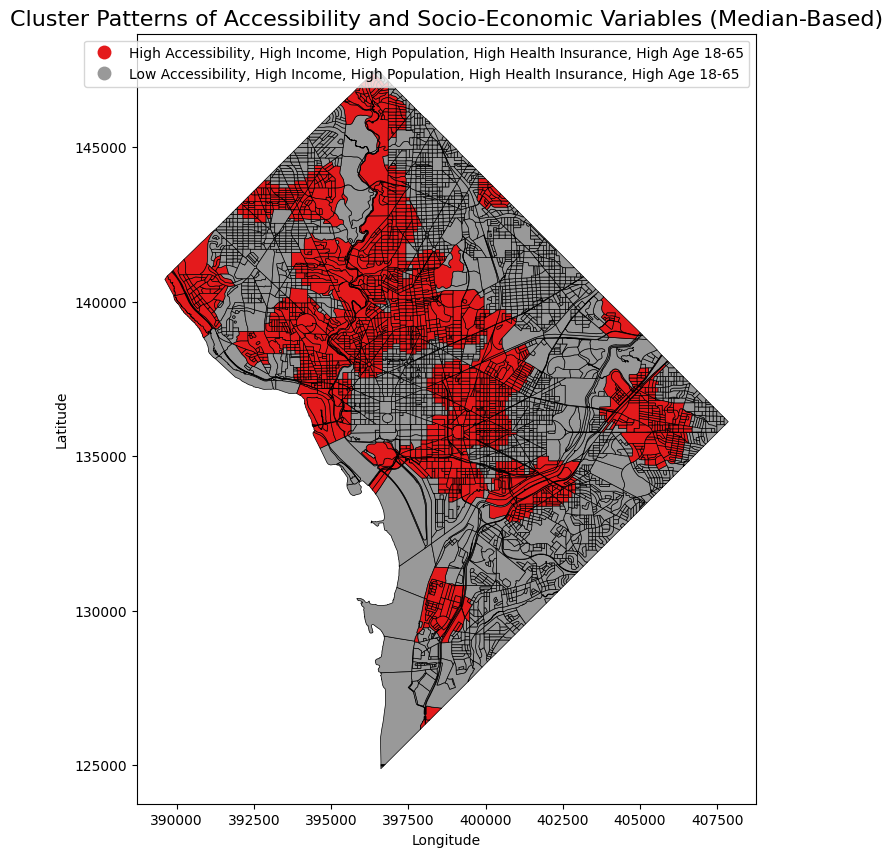

In [11]:
# Visualize the clusters with the new labels
fig, ax = plt.subplots(figsize=(12, 10))

# Use 'cluster_label' for coloring the map
populations.plot(column='cluster_label', cmap='Set1', linewidth=0.5, edgecolor='black', legend=True, ax=ax)

# Set title and labels
ax.set_title('Cluster Patterns of Accessibility and Socio-Economic Variables (Median-Based)', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Display the map with legend
plt.show()


In [12]:
import numpy as np

# Define the thresholds for low values based on the median
median_income = np.median(clustering_data['PerCapitaI'])
median_health_insurance = np.median(clustering_data['HI_block'])
median_age = np.median(clustering_data['age_18to65'])

# Filter for blocks that meet the low-income, low-health insurance, and low-age conditions
low_income_health_age = populations[
    (populations['PerCapitaI'] < median_income) &
    (populations['HI_block'] < median_health_insurance) &
    (populations['age_18to65'] < median_age)
]

# Display how many blocks meet the condition
print(f"Number of blocks with low income, health insurance, and age: {len(low_income_health_age)}")


Number of blocks with low income, health insurance, and age: 2032


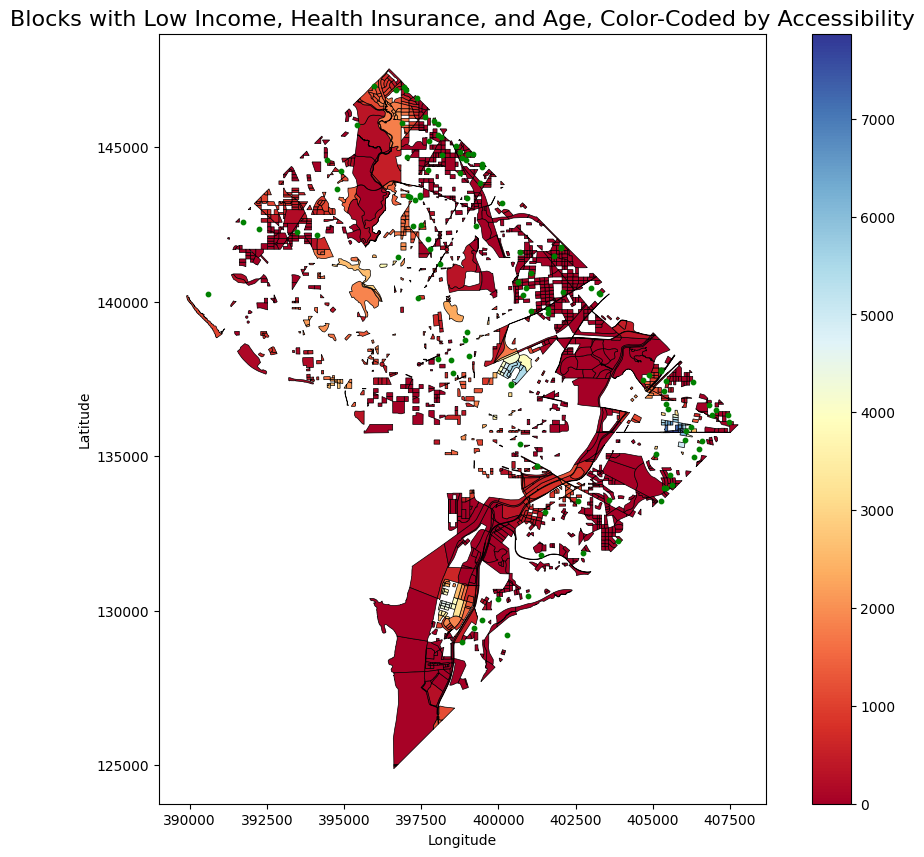

In [13]:
# Plot the filtered blocks color-coded by their accessibility
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the blocks filtered by low income, health insurance, and age, using 'accessibility' for color
low_income_health_age.plot(column='accessibility', cmap='RdYlBu', linewidth=0.5, edgecolor='black', legend=True, ax=ax)
schools.plot(ax=ax, color='green', markersize=10)

# Set title and labels
ax.set_title('Blocks with Low Income, Health Insurance, and Age, Color-Coded by Accessibility', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()


In [14]:
percentile_25_accessibility = np.percentile(populations['accessibility'], 25)
percentile_75_accessibility = np.percentile(populations['accessibility'], 75)
percentile_25_accessibility

0.0

/var/folders/r1/36h_p5t95dbgxw2n96kdly9m0000gn/T/ipykernel_2369/2465906291.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', num_combinations)  # Use 'tab20' colormap for up to 20 distinct colors


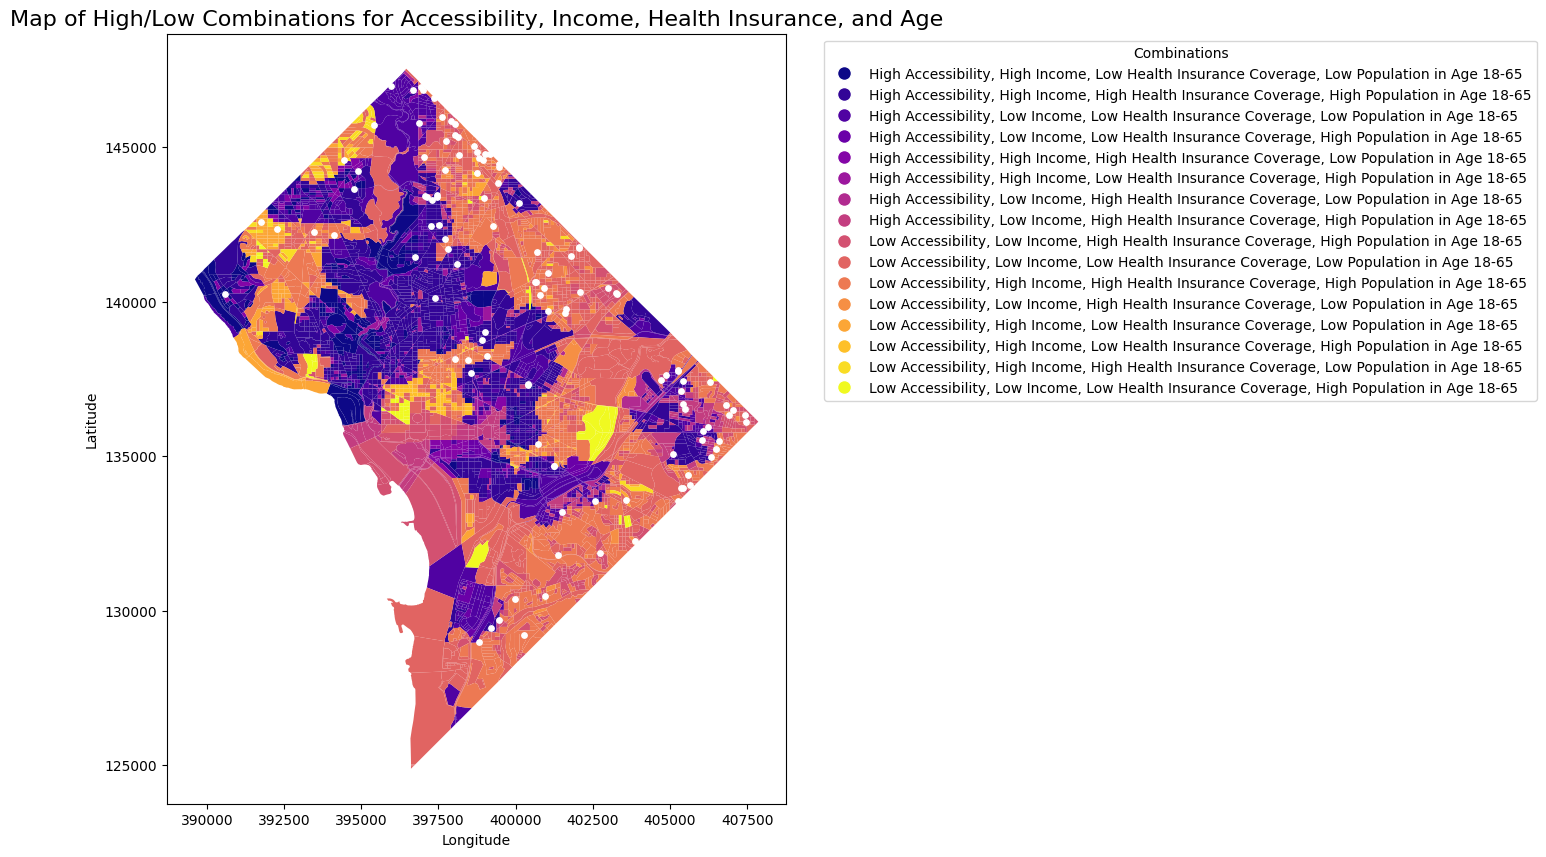

In [29]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import itertools

# Step 1: Calculate medians for the four attributes to classify them as High or Low
median_accessibility = np.median(populations['accessibility'])
median_income = np.median(populations['PerCapitaI'])
median_HI = np.median(populations['HI_block'])
median_age = np.median(populations['age_18to65'])

# Step 2: Define a function to classify each row with detailed labels
def classify_row(row):
    classification = []
    classification.append('High Accessibility' if row['accessibility'] >= median_accessibility else 'Low Accessibility')
    classification.append('High Income' if row['PerCapitaI'] >= median_income else 'Low Income')
    classification.append('High Health Insurance Coverage' if row['HI_block'] >= median_HI else 'Low Health Insurance Coverage')
    classification.append('High Population in Age 18-65' if row['age_18to65'] >= median_age else 'Low Population in Age 18-65')
    return ', '.join(classification)

# Step 3: Apply the classification function to each row and store the result in a new column
populations['classification'] = populations.apply(classify_row, axis=1)

# Step 4: Generate unique combinations for the classification
combinations = populations['classification'].unique()

# Step 5: Define colors for the different combinations
num_combinations = len(combinations)
colors = plt.cm.get_cmap('plasma', num_combinations)  # Use 'tab20' colormap for up to 20 distinct colors
combination_color_map = {combination: colors(i) for i, combination in enumerate(combinations)}

# Step 6: Create a plot
fig, ax = plt.subplots(figsize=(15, 10))

# Plot each unique classification with its corresponding color
for combination, color in combination_color_map.items():
    subset = populations[populations['classification'] == combination]
    subset.plot(ax=ax, color=color, label=combination)

# Step 7: Customize the legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=combination, markerfacecolor=color, markersize=10)
           for combination, color in combination_color_map.items()]
ax.legend(handles=handles, title='Combinations', bbox_to_anchor=(1.05, 1), loc='upper left')
schools.plot(ax=ax, color='white', markersize=15)

# Step 8: Set titles and labels
ax.set_title('Map of High/Low Combinations for Accessibility, Income, Health Insurance, and Age', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the plot
plt.show()



In [30]:
from arcgis.gis import GIS
from arcgis.mapping import WebMap
import arcgis
import pandas as pd
import numpy as np
import getpass



In [31]:
username= "ushaship_UofMD"
password=getpass.getpass()

········


In [61]:
# Step 1: Connect to ArcGIS Online
gis = GIS("http://www.arcgis.com",username,password)  # If you are already logged in through Jupyter Notebook, or use GIS("your_username", "your_password")


In [62]:
# Step 2: Prepare the data (ensure your GeoDataFrame 'populations' has the geometry and classification)
populations['classification'] = populations.apply(classify_row, axis=1)




In [65]:
populations.to_file("Census_blocks_DC_classified.shp", driver="ESRI Shapefile")


/var/folders/r1/36h_p5t95dbgxw2n96kdly9m0000gn/T/ipykernel_1222/1681223742.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  populations.to_file("Census_blocks_DC_classified.shp", driver="ESRI Shapefile")
/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'accessibility' to 'accessibil'
  ogr_write(
/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'accessibility_category' to 'accessib_1'
  ogr_write(
/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'classification' to 'classifica'
  ogr_write(


In [66]:
CBc = ['Census_blocks_DC_classified.shp', 'Census_blocks_DC_classified.shx', 'Census_blocks_DC_classified.dbf', 'Census_blocks_DC_classified.prj']
with zipfile.ZipFile('Census_blocks_DC_classified.zip', 'w') as zipf:
    for file in CBc:
        zipf.write(file)

# Upload the zipped shapefile
CBc_item = gis.content.add({'type': 'Shapefile'}, data="Census_blocks_DC_classified.zip")

# Publish it as a feature layer
CBc_layer_item = CBc_item.publish()

In [67]:
# Create a web map
web_map = WebMap()
# Add the published feature layer to the web map
web_map.add_layer(CBc_layer_item )




True

In [69]:
# Step 5: Customize the pop-ups to include the high/low classification and attribute info
popup_template = {
    "title": "Block Information",
    "content": """
    <b>Accessibility:</b> {accessibility} ({classification[0]})<br>
    <b>Per Capita Income:</b> {PerCapitaI} ({classification[1]})<br>
    <b>Health Insurance:</b> {HI_block} ({classification[2]})<br>
    <b>Age 18-65:</b> {age_18to65} ({classification[3]})<br>
    """
}

# Apply the popup to the layer
CBc_layer_item = popup_template


# Provide required properties for saving the web map
item_properties = {
    'title': 'Map showing the accessibilioty for ICFs in DC',
    'snippet': 'This map provides an insight into the accessibility scores and their income, age and health insurance coverage for each block in DC',
    'tags': ['accessibility', 'Washington DC', 'GIS', 'ICFs', 'Age','Income','Health Insurance']
}

# Save the web map with proper properties
web_map_item = web_map.save(item_properties)

# Optionally share the map
web_map_item.share(everyone=True)

print("Web map saved with ID:", web_map_item.id)


Web map saved with ID: f2227f61381d4853ad08f6626d4a0dd7


/opt/anaconda3/envs/arcgis_env/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: DeprecatedWarning: share is deprecated as of 2.3.0.1 and has be removed in 3.0.0. Use `Item.sharing` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
